In [1]:
# Project Objective / Problem Statement
# The goal of this project is to build a Handwritten Character Recognition model using the EMNIST dataset and a custom CNN architecture (CharNet).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
import os
import sys
import json
from sklearn.model_selection import train_test_split

# Add src to path
sys.path.append(os.path.abspath('..'))

from src.config import *
from src.data_loader import load_emnist_data, get_class_mapping
from src.preprocessing import preprocess_images, preprocess_labels, create_tf_dataset
from src.model import build_charnet
from src.train import compile_and_train
from src.evaluate import evaluate_model, plot_confusion_matrix, plot_training_history

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [2]:
# 1. Dataset Loading
(X_train_full, y_train_full), (X_test_raw, y_test_raw) = load_emnist_data()
class_mapping = get_class_mapping()


Loading EMNIST balanced dataset from local IDX files...


Loaded 112800 training samples and 18800 test samples.


In [3]:
# 2. Train/Validation Split (90/10) with Seed 42
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_train_full, y_train_full, 
    test_size=0.10, 
    random_state=42, 
    stratify=y_train_full
)

print("Training data shape:", X_train_raw.shape)
print("Validation data shape:", X_val_raw.shape)
print("Test data shape (held out):", X_test_raw.shape)


Training data shape: (101520, 28, 28)
Validation data shape: (11280, 28, 28)
Test data shape (held out): (18800, 28, 28)


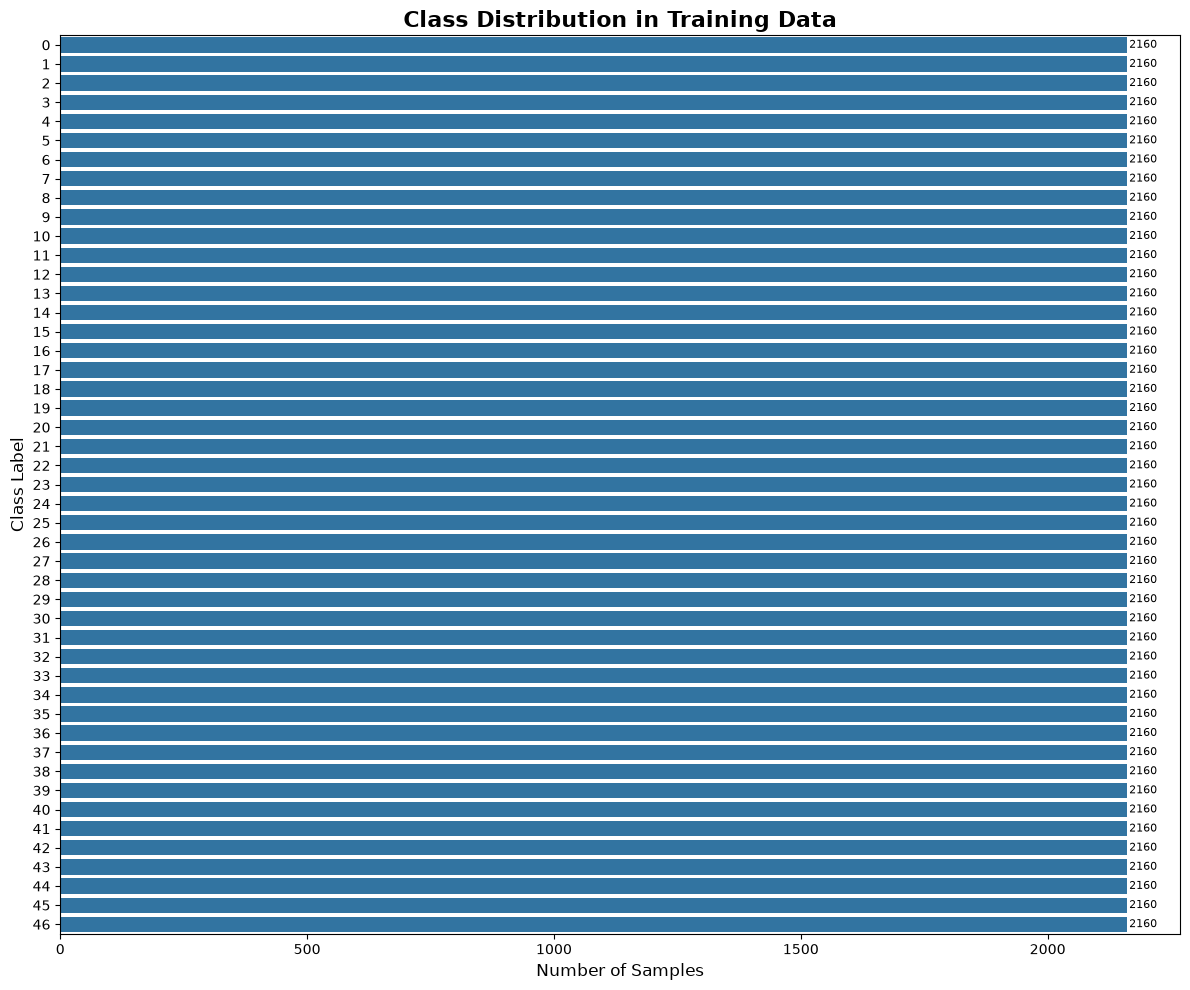

In [5]:
# 3. Class Distribution

class_counts = pd.Series(y_train_raw).value_counts().sort_index()

plt.figure(figsize=(12, 10))

ax = sns.barplot(
    x=class_counts.values,
    y=class_counts.index,
    orient='h'
)

plt.title('Class Distribution in Training Data', fontsize=16, fontweight='bold')
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Class Label', fontsize=12)

# Show count on each bar
for i, count in enumerate(class_counts.values):
    ax.text(count + 5, i, str(count), va='center', fontsize=8)

plt.tight_layout()
plt.show()

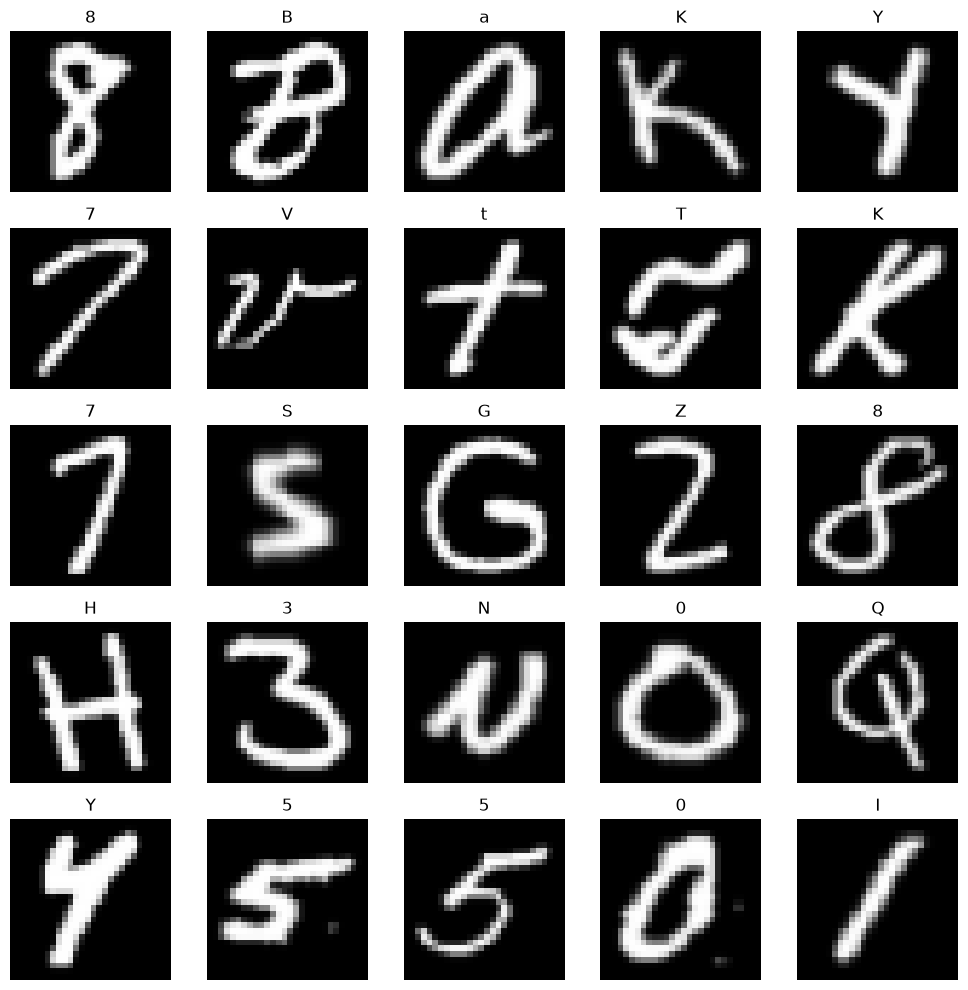

In [6]:
# 4. Visualization of Representative Images
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    # The raw EMNIST images are transposed, so we transpose back for visualization
    img = np.transpose(X_train_raw[i].reshape(28,28))
    plt.imshow(img, cmap='gray')
    plt.title(class_mapping[y_train_raw[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
# 5. Data Preprocessing
X_train = preprocess_images(X_train_raw)
X_val = preprocess_images(X_val_raw)
# We do NOT touch X_test_raw until final evaluation

y_train = preprocess_labels(y_train_raw, NUM_CLASSES)
y_val = preprocess_labels(y_val_raw, NUM_CLASSES)

print("Processed X_train shape:", X_train.shape)
print("Processed y_train shape:", y_train.shape)

Processed X_train shape: (101520, 28, 28, 1)
Processed y_train shape: (101520, 47)


In [8]:
# Create tf.data.Datasets
train_dataset = create_tf_dataset(X_train, y_train, BATCH_SIZE, shuffle=True)
val_dataset = create_tf_dataset(X_val, y_val, BATCH_SIZE, shuffle=False)


In [5]:
# 6. Model Architecture
model = build_charnet(num_classes=NUM_CLASSES)
model.summary()


Model: "CharNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 186,255 (727.56 KB)

 Trainable params: 185,103 (723.06 KB)

 Non-trainable params: 1,152 (4.50 KB)

In [10]:
# 7. Training Configuration

INITIAL_LR = 0.001
BATCH_SIZE = 128
EPOCHS = 30
PATIENCE = 5

print("Training Configuration")
print(f"Optimizer: Adam")
print(f"Learning Rate: {INITIAL_LR}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Maximum Epochs: {EPOCHS}")
print(f"EarlyStopping Patience: {PATIENCE}")

Training Configuration
Optimizer: Adam
Learning Rate: 0.001
Batch Size: 128
Maximum Epochs: 30
EarlyStopping Patience: 5


In [11]:
# 8 Model Training
print(f"Config: Adam(lr={INITIAL_LR}), Batch={BATCH_SIZE}, Max Epochs={EPOCHS}, Patience={PATIENCE}")
history = compile_and_train(
    model=model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    epochs=EPOCHS,
    initial_lr=INITIAL_LR,
    patience=PATIENCE
)

Config: Adam(lr=0.001), Batch=128, Max Epochs=30, Patience=5
Epoch 1/30


c:\Users\moham\OneDrive\Desktop\CodeAlpha\CodeAlpha_Handwritten_Character_Recognition\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


793/794 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.6184 - loss: 1.2954
Epoch 1: val_accuracy improved from None to 0.82793, saving model to c:\Users\moham\OneDrive\Desktop\CodeAlpha\CodeAlpha_Handwritten_Character_Recognition\models\charnet_best.keras

Epoch 1: finished saving model to c:\Users\moham\OneDrive\Desktop\CodeAlpha\CodeAlpha_Handwritten_Character_Recognition\models\charnet_best.keras
794/794 ━━━━━━━━━━━━━━━━━━━━ 131s 157ms/step - accuracy: 0.6183 - loss: 1.2954 - val_accuracy: 0.8279 - val_loss: 0.4948 - learning_rate: 0.0010
Epoch 2/30
793/794 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.8166 - loss: 0.5421
Epoch 2: val_accuracy improved from 0.82793 to 0.85647, saving model to c:\Users\moham\OneDrive\Desktop\CodeAlpha\CodeAlpha_Handwritten_Character_Recognition\models\charnet_best.keras

Epoch 2: finished saving model to c:\Users\moham\OneDrive\Desktop\CodeAlpha\CodeAlpha_Handwritten_Character_Recognition\models\charnet_best.keras
794/794 ━━━━━━━━━━━━━━━━━━━━ 12

In [12]:
# 9. Save Training History
results_dir = os.path.join(ROOT_DIR, 'results')
os.makedirs(results_dir, exist_ok=True)
history_path = os.path.join(results_dir, 'training_history.json')

hist_dict = {}
for key, val in history.history.items():
    hist_dict[key] = [float(v) for v in val]
    
with open(history_path, 'w') as f:
    json.dump(hist_dict, f, indent=4)
print(f"Training history saved to {history_path}")


Training history saved to c:\Users\moham\OneDrive\Desktop\CodeAlpha\CodeAlpha_Handwritten_Character_Recognition\results\training_history.json


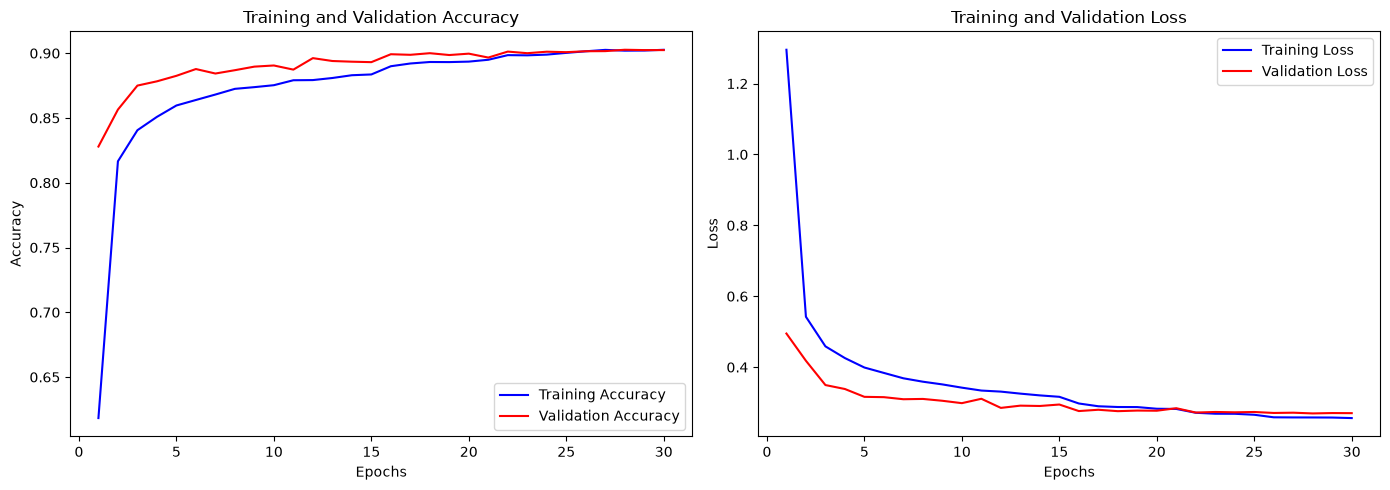

In [13]:
# 10. Training History Plots
plot_training_history(history)


In [7]:
# 11. Final Test Evaluation
X_test = preprocess_images(X_test_raw)
y_test = preprocess_labels(y_test_raw, NUM_CLASSES)
y_true, y_pred = evaluate_model(model, X_test, y_test, class_mapping)

Test Loss: 0.2748
Test Accuracy: 0.9032


  1/588 ━━━━━━━━━━━━━━━━━━━━ 3:09 323ms/step

  5/588 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step   

  9/588 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step

 13/588 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step

...

580/588 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

584/588 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

588/588 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

588/588 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step



Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.77      0.71       400
           1       0.57      0.79      0.66       400
           2       0.92      0.91      0.91       400
           3       0.99      0.99      0.99       400
           4       0.95      0.97      0.96       400
           5       0.97      0.92      0.94       400
           6       0.94      0.97      0.96       400
           7       0.98      0.99      0.99       400
           8       0.96      0.97      0.97       400
           9       0.70      0.85      0.77       400
           A       0.97      0.99      0.98       400
           B       0.98      0.98      0.98       400
           C       0.97      0.97      0.97       400
           D       0.96      0.93      0.95       400
           E       0.99      0.98      0.99       400
           F       0.75      0.54      0.63       400
           G       0.95      0.97      0.96       400
  

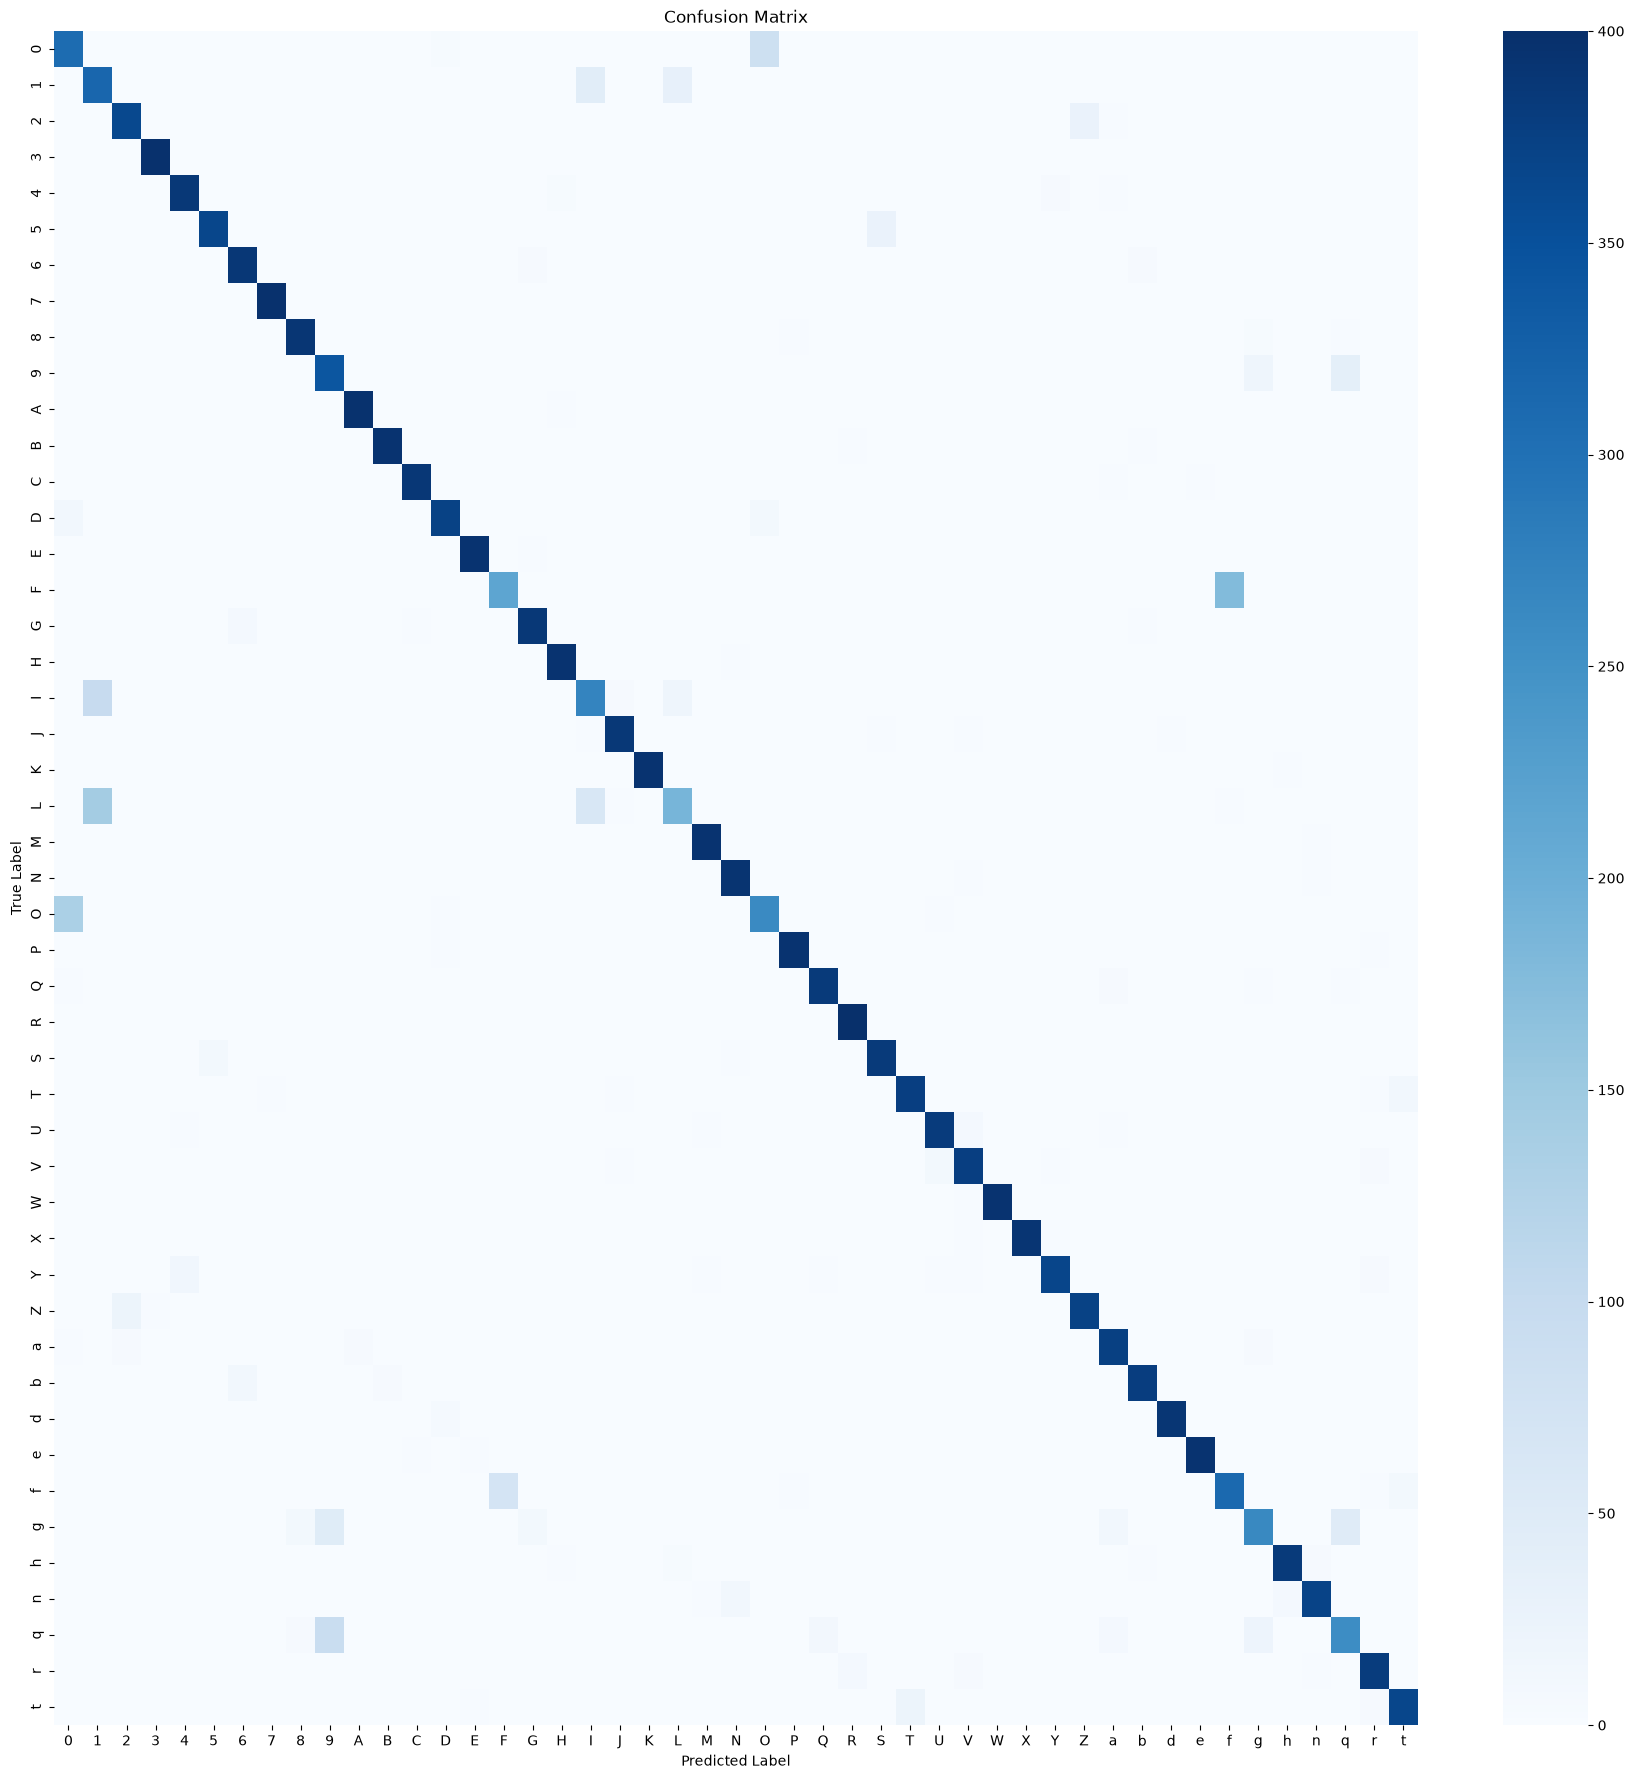

In [8]:
# 12. Confusion Matrix
import os
import matplotlib.pyplot as plt

_original_show = plt.show
def _custom_show(*args, **kwargs):
    results_dir = os.path.join(ROOT_DIR, 'results')
    os.makedirs(results_dir, exist_ok=True)
    plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'), bbox_inches='tight')
    _original_show(*args, **kwargs)

plt.show = _custom_show
try:
    plot_confusion_matrix(y_true, y_pred, class_mapping, figsize=(22, 22))
finally:
    plt.show = _original_show


Total incorrect predictions: 1819


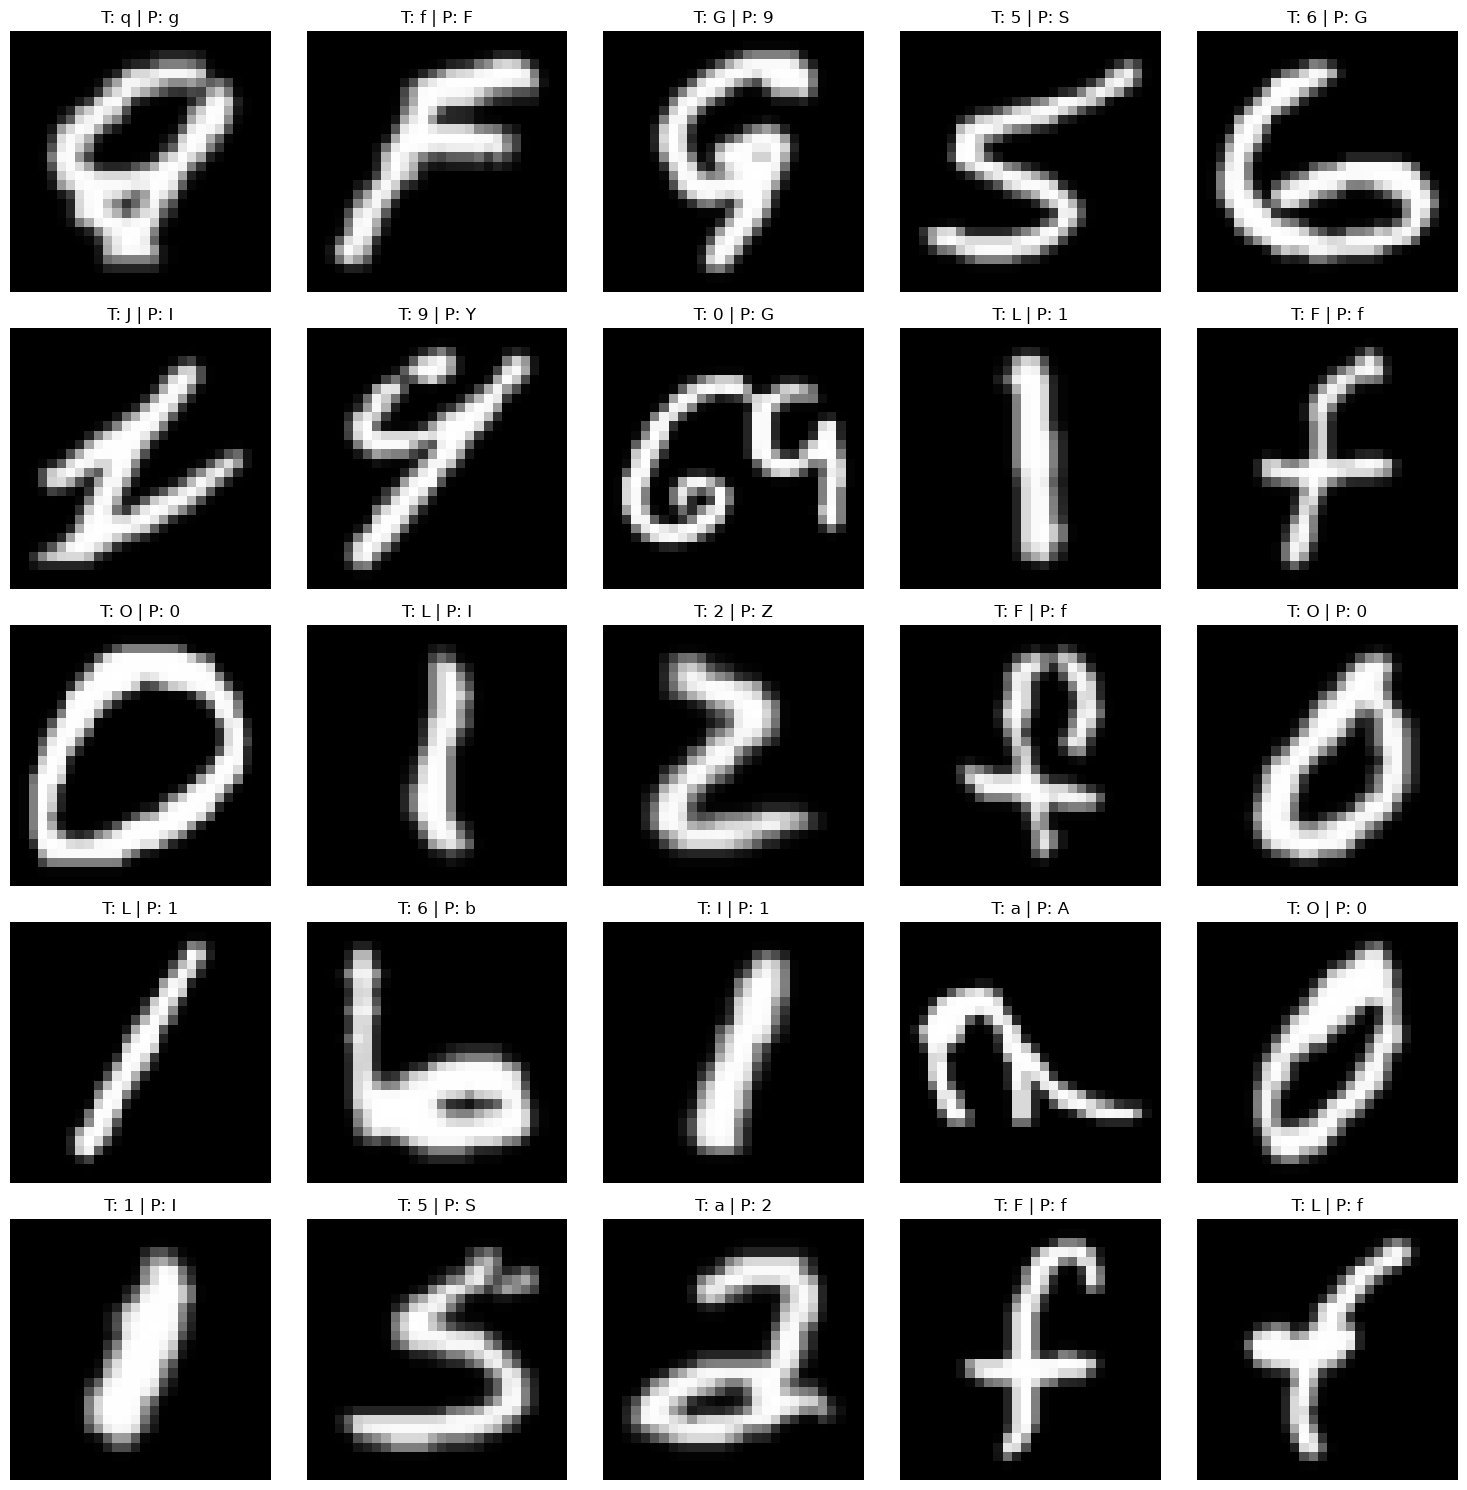

In [9]:
# 13. Error Analysis
incorrect_indices = np.where(y_true != y_pred)[0]
print(f"Total incorrect predictions: {len(incorrect_indices)}")
plt.figure(figsize=(15, 15))
for i, idx in enumerate(incorrect_indices[:25]):
    plt.subplot(5, 5, i+1)
    img = np.transpose(X_test_raw[idx].reshape(28,28))
    plt.imshow(img, cmap='gray')
    plt.title(f"T: {class_mapping[y_true[idx]]} | P: {class_mapping[y_pred[idx]]}")
    plt.axis('off')
plt.tight_layout()
results_dir = os.path.join(ROOT_DIR, 'results')
os.makedirs(results_dir, exist_ok=True)
plt.savefig(os.path.join(results_dir, 'error_analysis.png'), bbox_inches='tight')
plt.show()